# FDR 19 Significant Scalar Features

This notebook rebuilds the significant-feature summary behind `GAI 중간 결과/0527_main.html` slide 9 from the current CSV artifacts.

Key interpretation points:
- The 19 significant scalar features come from `data/processed/stats_results.csv` where `significant == True` after FDR-BH correction (`q < 0.05`).
- They are not Bonferroni-significant features. The older slide wording should be read as FDR-BH, not Bonferroni.
- Side/metric labels are kept explicit: `injured`, `contralateral`, `LSI`, and `asym`.
- `asym` is a metric attached to a joint-motion channel, not a separate anatomical cluster. Counting it again as an independent cluster double-counts knee/ankle rows.
- `dominant` is not a column-derived side label in the scalar feature table; Hip Flexion is described by speed concentration and side/metric labels instead.


In [1]:
from pathlib import Path
import ast
import re
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'figures' / 'analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

STATS_PATH = DATA / 'stats_results.csv'
RANKING_PATH = DATA / 'feature_ranking.csv'
SPM_PATH = DATA / 'spm_results.csv'
SPM_PAIR_PATH = DATA / 'spm_paired_results.csv'

OUT_CLUSTER = FIG_DIR / '04_significant_feature_clusters_fdr19.png'
OUT_DETAIL = FIG_DIR / '05_significant_feature_detail_fdr19.png'

STATS_PATH, RANKING_PATH, SPM_PATH, SPM_PAIR_PATH

(PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/data/processed/stats_results.csv'),
 PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/data/processed/feature_ranking.csv'),
 PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/data/processed/spm_results.csv'),
 PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/data/processed/spm_paired_results.csv'))

## Load and parse feature names

Feature naming convention used here:
- `*_injured`: value extracted from the injured/pseudo-injured side.
- `*_contralateral`: value extracted from the opposite side.
- `*_LSI`: `100 * injured / contralateral`.
- `*_asym`: Left/Right stance waveform difference area; it does not encode injured-vs-contralateral side.


In [2]:
def title_label(value: str) -> str:
    return value.replace('_', ' ').title()


def parse_feature_name(feature: str) -> pd.Series:
    side_metric = 'unknown'
    stem = feature
    for suffix, label in [
        ('_contralateral', 'contralateral'),
        ('_injured', 'injured'),
        ('_LSI', 'LSI'),
        ('_asym', 'asym'),
    ]:
        if stem.endswith(suffix):
            side_metric = label
            stem = stem[:-len(suffix)]
            break

    measure = 'asym area' if side_metric == 'asym' else 'unknown'
    for candidate in ['peak_timing', 'IC_angle', 'ROM', 'peak', 'min']:
        if stem.endswith('_' + candidate):
            measure = candidate
            stem = stem[:-(len(candidate) + 1)]
            break

    parts = stem.split('_')
    if len(parts) >= 2:
        joint = parts[0]
        motion = '_'.join(parts[1:])
        cluster = f'{title_label(joint)} {title_label(motion)}'
    else:
        joint = stem
        motion = ''
        cluster = title_label(stem)

    return pd.Series({
        'joint': title_label(joint),
        'motion': title_label(motion),
        'cluster': cluster,
        'measure': measure,
        'side_metric': side_metric,
        'is_lsi': side_metric == 'LSI',
        'is_asym': side_metric == 'asym',
    })


stats = pd.read_csv(STATS_PATH)
ranking = pd.read_csv(RANKING_PATH)
spm = pd.read_csv(SPM_PATH)
spm_pair = pd.read_csv(SPM_PAIR_PATH)

sig = stats[stats['significant'].astype(str).eq('True')].copy()
sig = pd.concat([sig, sig['feature'].apply(parse_feature_name)], axis=1)
sig['abs_d_ACLR_HA'] = sig['d_ACLR_HA'].abs()
sig = sig.sort_values(['cluster', 'speed', 'side_metric', 'measure']).reset_index(drop=True)

print(f'FDR-BH significant scalar features: {len(sig)}')
display(sig[['feature', 'cluster', 'speed', 'measure', 'side_metric', 'p_adj', 'eta2', 'd_ACLR_HA']])

FDR-BH significant scalar features: 19


,feature,cluster,speed,measure,side_metric,p_adj,eta2,d_ACLR_HA
0,ankle_adduction_peak_timing_LSI,Ankle Adduction,normal,peak_timing,LSI,0.006274,0.168106,1.003363
1,ankle_dorsiflexion_ROM_LSI,Ankle Dorsiflexion,fast,ROM,LSI,0.016539,0.185225,1.189109
2,ankle_dorsiflexion_min_LSI,Ankle Dorsiflexion,fast,min,LSI,0.021983,0.066858,0.973650
3,ankle_dorsiflexion_asym,Ankle Dorsiflexion,normal,asym area,asym,0.045894,0.117053,0.898651
4,ankle_dorsiflexion_ROM_LSI,Ankle Dorsiflexion,slow,ROM,LSI,0.022716,0.131998,1.018384
5,ankle_dorsiflexion_asym,Ankle Dorsiflexion,slow,asym area,asym,0.006088,0.191515,1.215684
6,hip_adduction_peak_contralateral,Hip Adduction,slow,peak,contralateral,0.033391,0.162122,0.950891
7,hip_flexion_IC_angle_LSI,Hip Flexion,fast,IC_angle,LSI,0.040343,0.156014,-1.112236
8,hip_flexion_ROM_LSI,Hip Flexion,fast,ROM,LSI,0.045894,0.144684,-1.028890
9,hip_flexion_peak_LSI,Hip Flexion,fast,peak,LSI,0.017322,0.173267,-1.166270


## Acceptance checks

These assertions keep the notebook aligned with the slide-correction target.


In [3]:
speed_counts = sig['speed'].value_counts().to_dict()
cluster_counts = sig['cluster'].value_counts().to_dict()
side_counts = sig['side_metric'].value_counts().to_dict()

expected_clusters = {
    'Knee Flexion': 7,
    'Hip Flexion': 5,
    'Ankle Dorsiflexion': 5,
    'Hip Adduction': 1,
    'Ankle Adduction': 1,
}
expected_sides = {'LSI': 9, 'asym': 5, 'injured': 4, 'contralateral': 1}

assert len(sig) == 19, len(sig)
assert speed_counts == {'fast': 10, 'slow': 5, 'normal': 4}, speed_counts
assert cluster_counts == expected_clusters, cluster_counts
assert sum(cluster_counts.values()) == 19, cluster_counts
assert side_counts == expected_sides, side_counts

bonferroni_like = ranking[ranking['p_adj'] < 0.05].copy()
print('FDR-BH q<0.05 count from stats_results.csv:', len(sig))
print('Bonferroni-style p_adj<0.05 count from feature_ranking.csv:', len(bonferroni_like))
print('Speed counts:', speed_counts)
print('Exclusive cluster counts:', cluster_counts)
print('Side/metric counts:', side_counts)

FDR-BH q<0.05 count from stats_results.csv: 19
Bonferroni-style p_adj<0.05 count from feature_ranking.csv: 6
Speed counts: {'fast': 10, 'slow': 5, 'normal': 4}
Exclusive cluster counts: {'Knee Flexion': 7, 'Ankle Dorsiflexion': 5, 'Hip Flexion': 5, 'Ankle Adduction': 1, 'Hip Adduction': 1}
Side/metric counts: {'LSI': 9, 'asym': 5, 'injured': 4, 'contralateral': 1}


## Figure 1: slide-ready cluster summary

This figure separates exclusive anatomical clusters from metric families. That is the key correction: `Asymmetry` should not be summed as a sixth anatomical cluster because its rows already belong to Knee Flexion or Ankle Dorsiflexion.


PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/figures/analysis/04_significant_feature_clusters_fdr19.png')

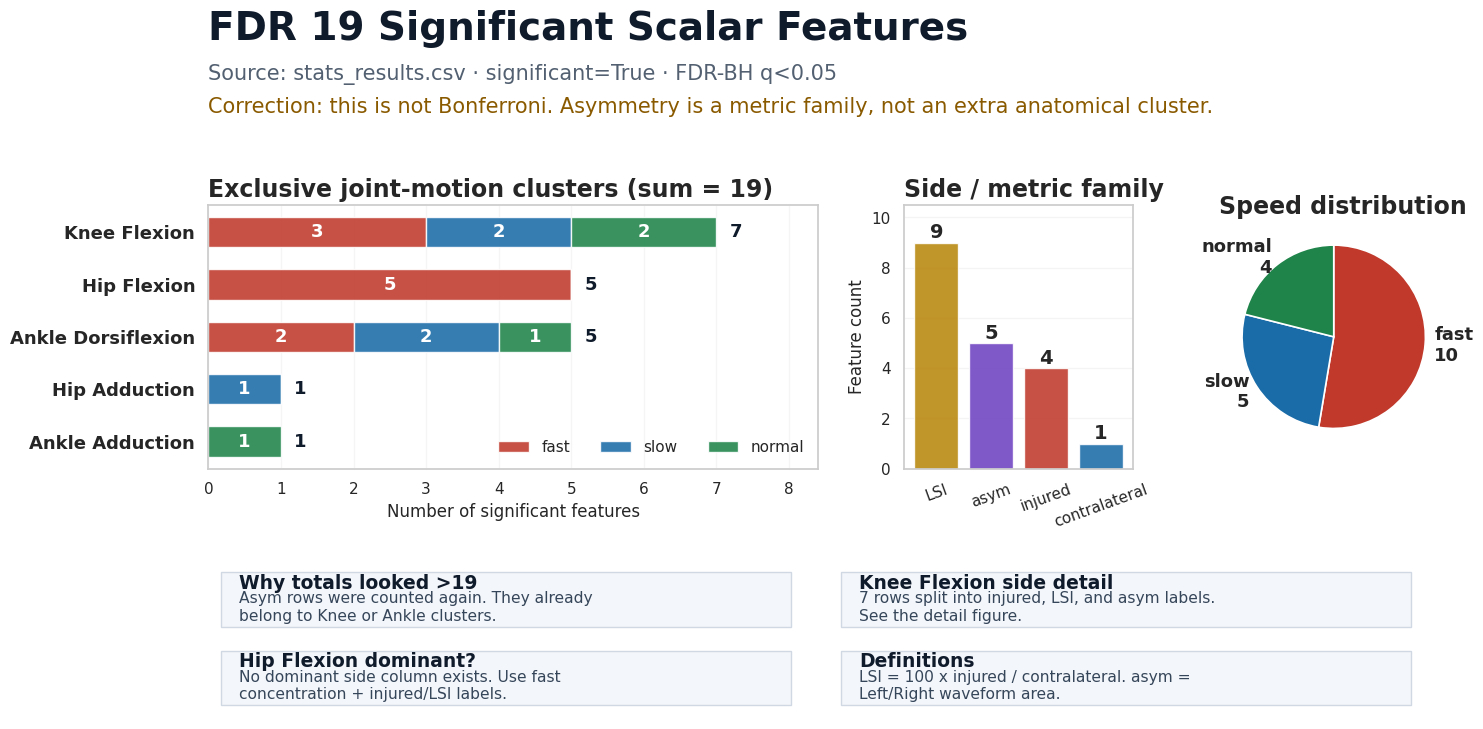

In [4]:
speed_order = ['fast', 'slow', 'normal']
speed_palette = {'fast': '#c0392b', 'slow': '#1a6ca8', 'normal': '#1e8449'}
metric_palette = {'LSI': '#b8860b', 'asym': '#6f42c1', 'injured': '#c0392b', 'contralateral': '#1a6ca8'}
cluster_order = ['Knee Flexion', 'Hip Flexion', 'Ankle Dorsiflexion', 'Hip Adduction', 'Ankle Adduction']
metric_order = ['LSI', 'asym', 'injured', 'contralateral']

cluster_speed = (
    sig.groupby(['cluster', 'speed']).size()
    .unstack(fill_value=0)
    .reindex(cluster_order)
    .reindex(columns=speed_order, fill_value=0)
)
metric_counts = sig['side_metric'].value_counts().reindex(metric_order).fillna(0).astype(int)

fig = plt.figure(figsize=(16, 9), constrained_layout=False)
gs = fig.add_gridspec(3, 4, height_ratios=[0.9, 2.4, 1.55], width_ratios=[1.35, 1.05, 1.05, 1.05], hspace=0.45, wspace=0.35)

ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(0.0, 0.86, 'FDR 19 Significant Scalar Features', fontsize=28, fontweight='bold', color='#0f1a2b', transform=ax_title.transAxes)
ax_title.text(0.0, 0.46, 'Source: stats_results.csv · significant=True · FDR-BH q<0.05', fontsize=15, color='#526071', transform=ax_title.transAxes)
ax_title.text(0.0, 0.12, 'Correction: this is not Bonferroni. Asymmetry is a metric family, not an extra anatomical cluster.', fontsize=15, color='#8a5a00', transform=ax_title.transAxes)

ax_cluster = fig.add_subplot(gs[1, :2])
bottom = np.zeros(len(cluster_speed))
y = np.arange(len(cluster_speed))
for speed in speed_order:
    vals = cluster_speed[speed].to_numpy()
    ax_cluster.barh(y, vals, left=bottom, color=speed_palette[speed], alpha=0.88, label=speed, height=0.58)
    for idx, v in enumerate(vals):
        if v:
            ax_cluster.text(bottom[idx] + v / 2, idx, str(int(v)), ha='center', va='center', color='white', fontsize=13, fontweight='bold')
    bottom += vals
for idx, total in enumerate(bottom):
    ax_cluster.text(total + 0.18, idx, f'{int(total)}', va='center', fontsize=13, fontweight='bold', color='#0f1a2b')
ax_cluster.set_yticks(y)
ax_cluster.set_yticklabels(cluster_speed.index, fontsize=13, fontweight='bold')
ax_cluster.invert_yaxis()
ax_cluster.set_xlim(0, max(bottom) + 1.4)
ax_cluster.set_xlabel('Number of significant features')
ax_cluster.set_title('Exclusive joint-motion clusters (sum = 19)', loc='left', fontsize=17, fontweight='bold')
ax_cluster.legend(frameon=False, ncol=3, loc='lower right')
ax_cluster.grid(axis='x', alpha=0.18)
ax_cluster.grid(axis='y', visible=False)

ax_metric = fig.add_subplot(gs[1, 2])
metric_vals = metric_counts.to_numpy()
metric_colors = [metric_palette[m] for m in metric_counts.index]
ax_metric.bar(metric_counts.index, metric_vals, color=metric_colors, alpha=0.88)
for idx, v in enumerate(metric_vals):
    ax_metric.text(idx, v + 0.18, str(int(v)), ha='center', fontsize=14, fontweight='bold')
ax_metric.set_ylim(0, max(metric_vals) + 1.5)
ax_metric.set_title('Side / metric family', loc='left', fontsize=17, fontweight='bold')
ax_metric.set_ylabel('Feature count')
ax_metric.tick_params(axis='x', labelrotation=20)
ax_metric.grid(axis='y', alpha=0.2)
ax_metric.grid(axis='x', visible=False)

ax_speed = fig.add_subplot(gs[1, 3])
speed_vals = pd.Series(speed_counts).reindex(speed_order).fillna(0).astype(int)
ax_speed.pie(
    speed_vals,
    labels=[f'{idx}\n{val}' for idx, val in speed_vals.items()],
    colors=[speed_palette[s] for s in speed_order],
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 13, 'fontweight': 'bold'},
    wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'},
)
ax_speed.set_title('Speed distribution', loc='left', fontsize=17, fontweight='bold')

ax_note = fig.add_subplot(gs[2, :])
ax_note.axis('off')
notes = [
    ('Why totals looked >19', 'Asym rows were counted again. They already belong to Knee or Ankle clusters.'),
    ('Knee Flexion side detail', '7 rows split into injured, LSI, and asym labels. See the detail figure.'),
    ('Hip Flexion dominant?', 'No dominant side column exists. Use fast concentration + injured/LSI labels.'),
    ('Definitions', 'LSI = 100 x injured / contralateral. asym = Left/Right waveform area.'),
]
for i, (head, body) in enumerate(notes):
    x = 0.01 + (i % 2) * 0.5
    y0 = 0.72 - (i // 2) * 0.46
    ax_note.add_patch(plt.Rectangle((x, y0 - 0.18), 0.46, 0.32, transform=ax_note.transAxes, facecolor='#f3f6fa', edgecolor='#d0d8e4', linewidth=1.0))
    ax_note.text(x + 0.015, y0 + 0.045, head, transform=ax_note.transAxes, fontsize=13.5, fontweight='bold', color='#0f1a2b')
    ax_note.text(x + 0.015, y0 - 0.065, textwrap.fill(body, width=48), transform=ax_note.transAxes, fontsize=11.2, color='#36465a', va='center')

fig.savefig(OUT_CLUSTER, dpi=220, bbox_inches='tight')
OUT_CLUSTER

## Figure 2: all 19 significant features with side/metric labels

The table-style figure is designed for checking exactly which side or metric each cluster row represents.


PosixPath('/Users/ryutt/Desktop/mini_ryutt/Walking/figures/analysis/05_significant_feature_detail_fdr19.png')

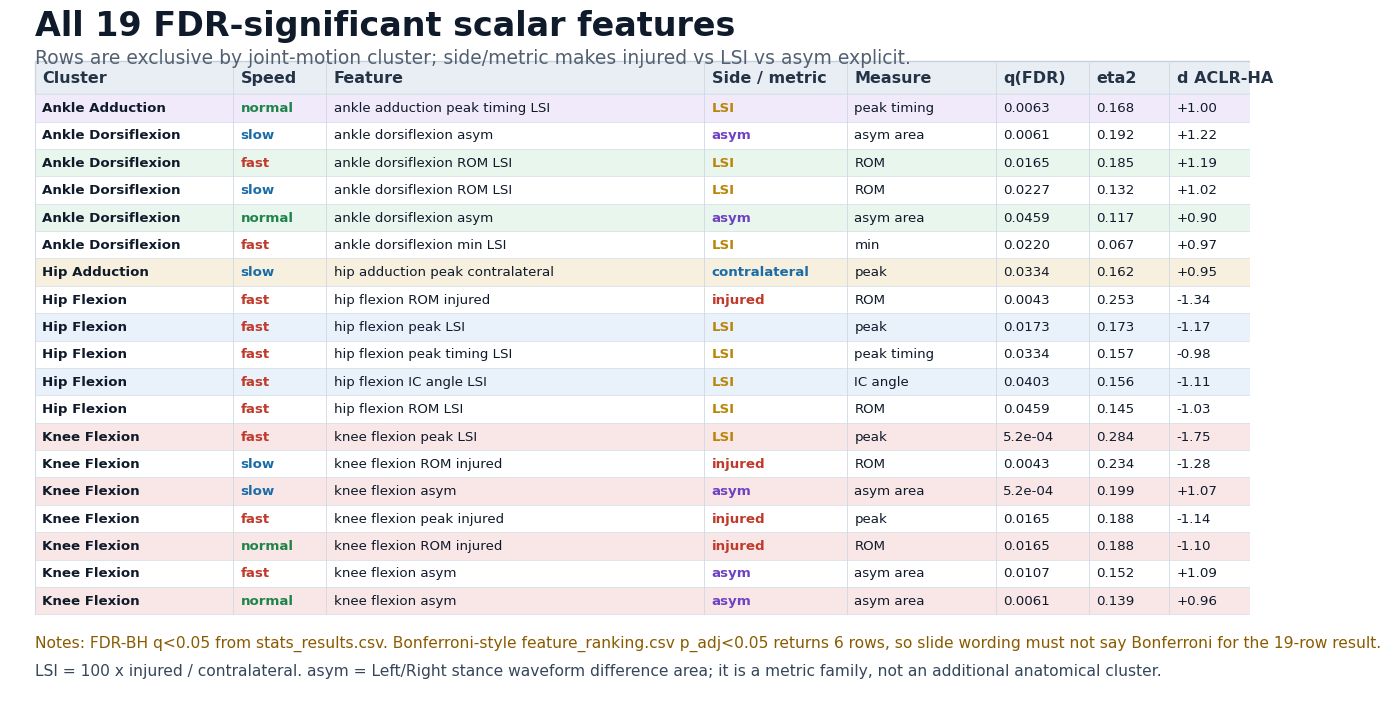

In [5]:
detail = sig.copy()
detail['feature_display'] = detail['feature'].str.replace('_', ' ', regex=False)
detail['q'] = detail['p_adj'].map(lambda x: f'{x:.4f}' if x >= 0.001 else f'{x:.1e}')
detail['eta2_fmt'] = detail['eta2'].map(lambda x: f'{x:.3f}')
detail['d_fmt'] = detail['d_ACLR_HA'].map(lambda x: f'{x:+.2f}')
detail['rank'] = detail['eta2'].rank(method='first', ascending=False).astype(int)
detail = detail.sort_values(['cluster', 'rank']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')
fig.patch.set_facecolor('white')

columns = ['Cluster', 'Speed', 'Feature', 'Side / metric', 'Measure', 'q(FDR)', 'eta2', 'd ACLR-HA']
col_widths = [0.16, 0.075, 0.305, 0.115, 0.12, 0.075, 0.065, 0.085]
x_edges = np.cumsum([0] + col_widths)
row_h = 0.0395
header_h = 0.048
x0 = 0.02
y_top = 0.88

ax.text(x0, 0.965, 'All 19 FDR-significant scalar features', fontsize=24, fontweight='bold', color='#0f1a2b', transform=ax.transAxes)
ax.text(x0, 0.925, 'Rows are exclusive by joint-motion cluster; side/metric makes injured vs LSI vs asym explicit.', fontsize=13.5, color='#526071', transform=ax.transAxes)

# Header
ax.add_patch(plt.Rectangle((x0, y_top), sum(col_widths), header_h, transform=ax.transAxes, facecolor='#e9eef5', edgecolor='#c6d0dc', linewidth=1.0))
for col, x_left, width in zip(columns, x_edges[:-1], col_widths):
    ax.text(x0 + x_left + 0.006, y_top + header_h / 2, col, va='center', ha='left', fontsize=11.5, fontweight='bold', color='#243447', transform=ax.transAxes)

cluster_colors = {
    'Knee Flexion': '#f8e7e6',
    'Hip Flexion': '#e9f1fb',
    'Ankle Dorsiflexion': '#e9f6ee',
    'Hip Adduction': '#f7f0df',
    'Ankle Adduction': '#f1eafa',
}

for i, row in detail.iterrows():
    y = y_top - (i + 1) * row_h
    bg = cluster_colors.get(row['cluster'], '#ffffff') if i % 2 == 0 else '#ffffff'
    ax.add_patch(plt.Rectangle((x0, y), sum(col_widths), row_h, transform=ax.transAxes, facecolor=bg, edgecolor='#dbe2ea', linewidth=0.6))
    values = [
        row['cluster'],
        row['speed'],
        row['feature_display'],
        row['side_metric'],
        row['measure'].replace('_', ' '),
        row['q'],
        row['eta2_fmt'],
        row['d_fmt'],
    ]
    for value, x_left, width in zip(values, x_edges[:-1], col_widths):
        color = '#0f1a2b'
        weight = 'normal'
        if value in speed_palette:
            color = speed_palette[value]
            weight = 'bold'
        if value in metric_palette:
            color = metric_palette[value]
            weight = 'bold'
        if x_left == 0:
            weight = 'bold'
        ax.text(x0 + x_left + 0.006, y + row_h / 2, str(value), va='center', ha='left', fontsize=9.6, color=color, fontweight=weight, transform=ax.transAxes)

# Column guides
for x in x_edges:
    ax.plot([x0 + x, x0 + x], [y_top - len(detail) * row_h, y_top + header_h], color='#cfd8e3', linewidth=0.6, transform=ax.transAxes)

foot_y = y_top - (len(detail) + 1.2) * row_h
ax.text(x0, foot_y, 'Notes: FDR-BH q<0.05 from stats_results.csv. Bonferroni-style feature_ranking.csv p_adj<0.05 returns 6 rows, so slide wording must not say Bonferroni for the 19-row result.', fontsize=11.2, color='#8a5a00', transform=ax.transAxes)
ax.text(x0, foot_y - 0.04, 'LSI = 100 x injured / contralateral. asym = Left/Right stance waveform difference area; it is a metric family, not an additional anatomical cluster.', fontsize=11.2, color='#36465a', transform=ax.transAxes)

fig.savefig(OUT_DETAIL, dpi=220, bbox_inches='tight')
OUT_DETAIL

## SPM1D significant channels

SPM1D results are not part of the 19 scalar-feature count. They are shown separately to keep waveform and scalar evidence from being mixed.


In [6]:
spm_sig = spm[spm['significant'].astype(str).eq('True')].copy()
spm_pair_sig = spm_pair[spm_pair['significant'].astype(str).eq('True')].copy()

print('SPM 3-group significant rows:')
display(spm_sig[['channel', 'speed', 'f_max', 'sig_intervals']])
print('SPM paired significant rows:')
display(spm_pair_sig[['channel', 'speed', 't_max', 'sig_intervals']])

SPM 3-group significant rows:


,channel,speed,f_max,sig_intervals
11,knee_adduction,fast,9.316302,"[(78, 87)]"
14,knee_int_rotation,fast,7.987405,"[(20, 30), (80, 86)]"
17,knee_flexion,fast,7.569944,"[(0, 4), (75, 82), (100, 100)]"


SPM paired significant rows:


,channel,speed,t_max,sig_intervals
15,knee_flexion,normal,3.333024,"[(35, 41), (98, 98)]"


## Output validation

In [7]:
for path in [OUT_CLUSTER, OUT_DETAIL]:
    assert path.exists(), path
    assert path.stat().st_size > 0, path
    print(path.relative_to(ROOT), f'{path.stat().st_size:,} bytes')

figures/analysis/04_significant_feature_clusters_fdr19.png 336,240 bytes
figures/analysis/05_significant_feature_detail_fdr19.png 518,003 bytes
